In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import files

uploaded = files.upload()

Saving bank-full.csv to bank-full (1).csv


In [6]:
import pandas as pd

df = pd.read_csv("bank-full.csv", sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [8]:
import os
print(os.listdir())

['.config', 'bank-full.csv', 'bank-full (1).csv', 'sample_data']


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [14]:
total_contacts = len(df)
print("Total Contacts:", total_contacts)

Total Contacts: 45211


In [15]:
total_conversions = len(df[df['y'] == 'yes'])
print("Total Conversions:", total_conversions)

Total Conversions: 5289


In [16]:
conversion_rate = (total_conversions / total_contacts) * 100
print(f"Conversion Rate: {conversion_rate:.2f}%")

Conversion Rate: 11.70%


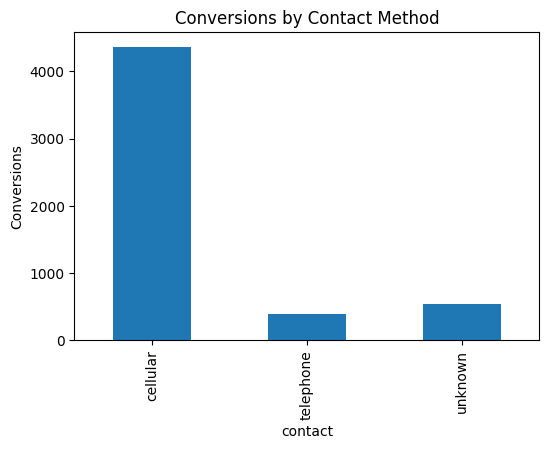

In [17]:
import matplotlib.pyplot as plt

contact_conv = df[df['y'] == 'yes'].groupby('contact').size()

plt.figure(figsize=(6,4))
contact_conv.plot(kind='bar')
plt.title("Conversions by Contact Method")
plt.ylabel("Conversions")
plt.show()

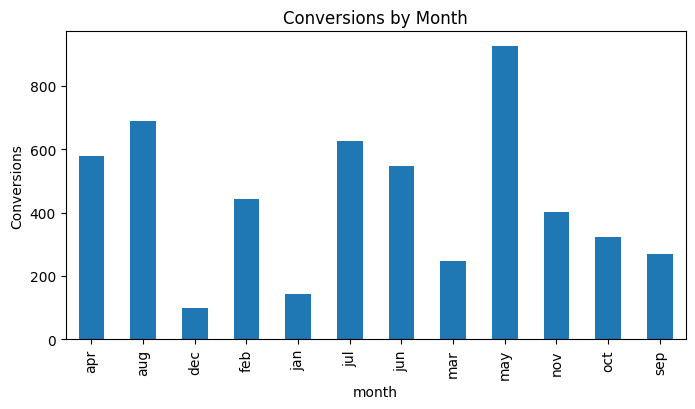

In [18]:
month_conv = df[df['y'] == 'yes'].groupby('month').size()

plt.figure(figsize=(8,4))
month_conv.plot(kind='bar')
plt.title("Conversions by Month")
plt.ylabel("Conversions")
plt.show()

/tmp/ipykernel_1139/3800803335.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_conv = df[df['y'] == 'yes'].groupby('Age Group').size()


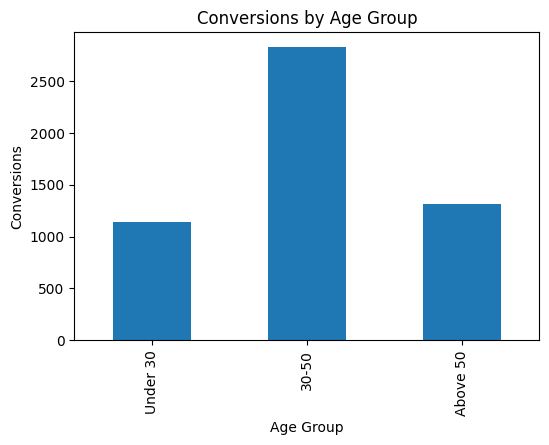

In [19]:
df['Age Group'] = pd.cut(
    df['age'],
    bins=[0, 30, 50, 100],
    labels=['Under 30', '30-50', 'Above 50']
)

age_conv = df[df['y'] == 'yes'].groupby('Age Group').size()

plt.figure(figsize=(6,4))
age_conv.plot(kind='bar')
plt.title("Conversions by Age Group")
plt.ylabel("Conversions")
plt.show()

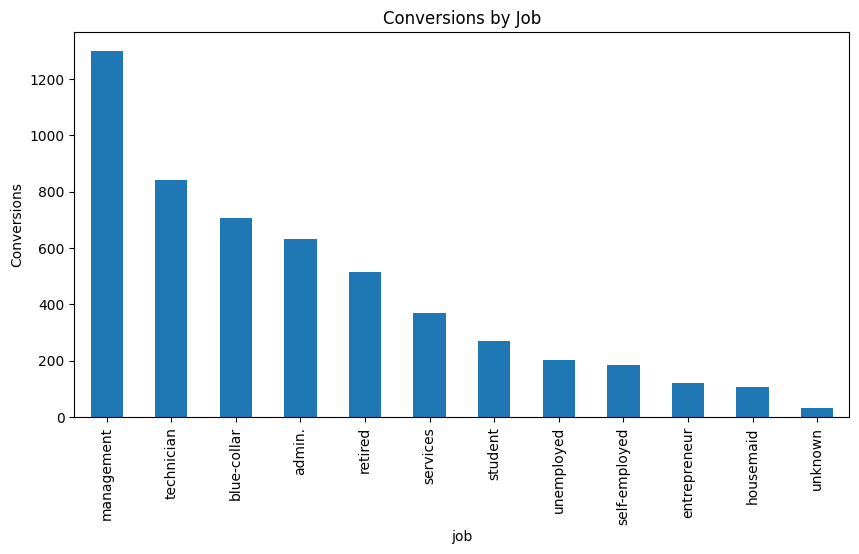

In [20]:
job_conv = df[df['y'] == 'yes'].groupby('job').size().sort_values(ascending=False)

plt.figure(figsize=(10,5))
job_conv.plot(kind='bar')
plt.title("Conversions by Job")
plt.ylabel("Conversions")
plt.show()

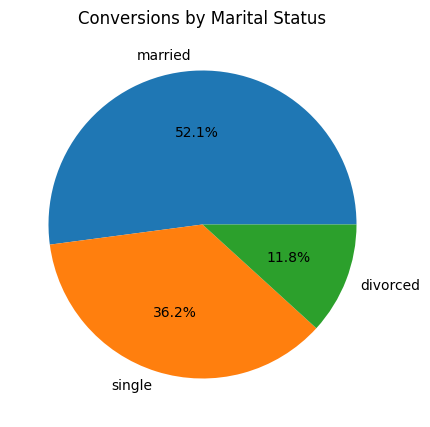

In [21]:
marital_conv = df[df['y'] == 'yes']['marital'].value_counts()

plt.figure(figsize=(5,5))
plt.pie(marital_conv, labels=marital_conv.index, autopct='%1.1f%%')
plt.title("Conversions by Marital Status")
plt.show()

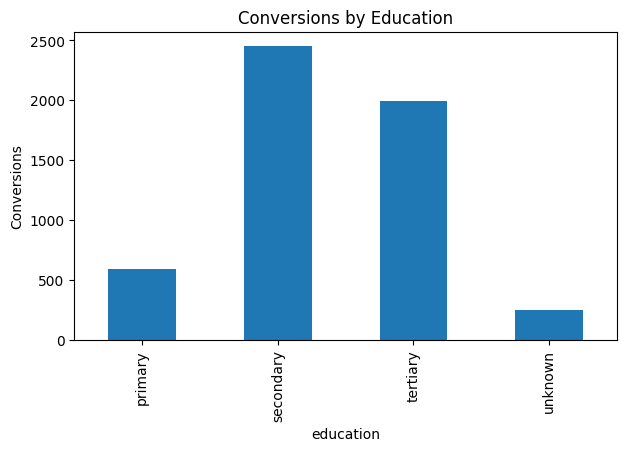

In [22]:
education_conv = df[df['y'] == 'yes'].groupby('education').size()

plt.figure(figsize=(7,4))
education_conv.plot(kind='bar')
plt.title("Conversions by Education")
plt.ylabel("Conversions")
plt.show()

Key Insights

• Total Contacts: 45,211
• Total Conversions: 5,289
• Conversion Rate: 11.70%
• Cellular contact method achieved the highest conversions.
• Customers aged 30–50 showed strong conversion performance.
• Married customers contributed a significant share of conversions.
• Conversion rates varied across occupations and education levels.

Recommendations

• Focus marketing efforts on high-performing contact channels.
• Target customer segments with higher conversion rates.
• Optimize campaign timing based on monthly performance.
• Create personalized campaigns for different occupations.
• Improve follow-up strategies to increase conversions.
